# 🏥 Healthcare No-Show Predictor
## Notebook 3: Model Training & Comparison

**Goal:** Train and compare three ML models on the no-show dataset.

**Models:**
1. K-Nearest Neighbors (KNN)
2. Naive Bayes
3. Logistic Regression

**What we measure:**
- Accuracy
- Training time
- Predictions on test set

In [16]:
# ── Imports ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)

%matplotlib inline
print("✅ Libraries loaded")

✅ Libraries loaded


In [17]:
# ── Load Preprocessed Data ────────────────────────────
X_train = np.load('../data/X_train.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')

feature_names = pd.read_csv(
    '../data/feature_names.csv').iloc[:, 0].tolist()

print("=== DATA LOADED ===")
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_test  shape : {y_test.shape}")
print(f"\nFeatures: {feature_names}")
print(f"\nClass distribution in training:")
print(f"  Showed up : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  No show   : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print("\n✅ Data ready for modeling")

=== DATA LOADED ===
X_train shape : (57567, 12)
X_test  shape : (14392, 12)
y_train shape : (57567,)
y_test  shape : (14392,)

Features: ['age', 'gender_binary', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'waiting_days', 'age_group', 'same_day', 'appt_weekday']

Class distribution in training:
  Showed up : 41,149 (71.5%)
  No show   : 16,418 (28.5%)

✅ Data ready for modeling


## Helper Function
We define a helper function to train, predict and 
evaluate any model consistently.
This avoids repeating the same code three times.

In [18]:
# ── Helper Function ───────────────────────────────────
def train_and_evaluate(model, model_name, 
                        X_train, y_train,
                        X_test,  y_test):
    """
    Trains a model and returns evaluation results.
    Input:
        model      : sklearn model object
        model_name : string name for display
        X_train    : training features
        y_train    : training labels
        X_test     : test features
        y_test     : test labels
    Output:
        results dict with accuracy, predictions, time
    """
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")

    # Train
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    print(f"Training time : {train_time:.2f} seconds")

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test,  y_pred_test)

    print(f"Train accuracy: {train_acc*100:.2f}%")
    print(f"Test  accuracy: {test_acc*100:.2f}%")

    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(
        y_test, y_pred_test,
        target_names=['Showed Up', 'No Show']))

    return {
        'name'        : model_name,
        'model'       : model,
        'train_acc'   : train_acc,
        'test_acc'    : test_acc,
        'train_time'  : train_time,
        'y_pred'      : y_pred_test
    }

print("✅ Helper function defined")

✅ Helper function defined


## Model 1: K-Nearest Neighbors (KNN)

**How it works:**
- For each test point find k closest training points
- Majority vote among neighbors → prediction
- You built this from scratch in eCornell! ✅

**Key hyperparameter:**
- k = number of neighbors to consider
- Small k → complex boundary, can overfit
- Large k → smooth boundary, can underfit

=== FINDING BEST K ===

k= 3  accuracy=65.56%
k= 5  accuracy=66.89%
k= 7  accuracy=67.63%
k=10  accuracy=69.93%
k=15  accuracy=69.74%
k=20  accuracy=70.48%

✅ Best k = 20


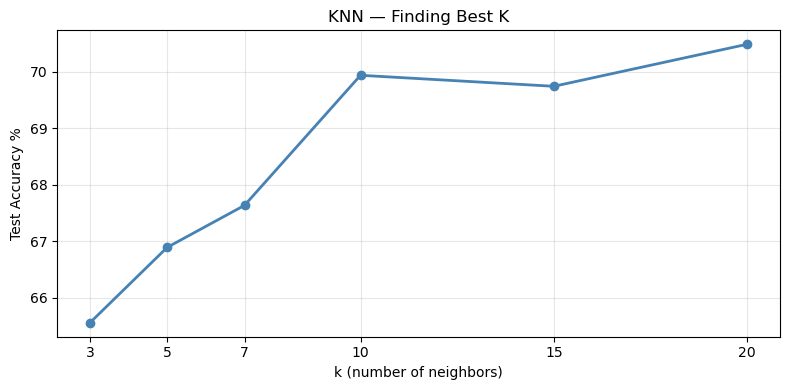

In [19]:
# ── Model 1: KNN ─────────────────────────────────────
# Try different k values first
print("=== FINDING BEST K ===\n")

k_values  = [3, 5, 7, 10, 15, 20]
k_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    k_results.append(acc)
    print(f"k={k:2d}  accuracy={acc*100:.2f}%")

best_k = k_values[np.argmax(k_results)]
print(f"\n✅ Best k = {best_k}")

# Plot k vs accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_values, [r*100 for r in k_results],
         marker='o', color='steelblue', linewidth=2)
plt.xlabel('k (number of neighbors)')
plt.ylabel('Test Accuracy %')
plt.title('KNN — Finding Best K')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ── Train Final KNN with Best K ───────────────────────
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_results = train_and_evaluate(
    knn_model, f"KNN (k={best_k})",
    X_train, y_train,
    X_test,  y_test
)


  KNN (k=20)
Training time : 0.02 seconds
Train accuracy: 72.23%
Test  accuracy: 70.48%

Classification Report:
              precision    recall  f1-score   support

   Showed Up       0.72      0.96      0.82     10288
     No Show       0.38      0.06      0.10      4104

    accuracy                           0.70     14392
   macro avg       0.55      0.51      0.46     14392
weighted avg       0.62      0.70      0.62     14392



## Model 2: Naive Bayes

**How it works:**
- Uses Bayes theorem with independence assumption
- P(no_show | features) ∝ P(features | no_show) × P(no_show)
- You calculated this by hand for Flu vs Cold! ✅

**Gaussian NB:**
- Assumes each feature follows a normal distribution
- Fast to train — just computes mean and variance per class
- Works well even with limited data

In [21]:
# ── Model 2: Naive Bayes ──────────────────────────────
nb_model   = GaussianNB()
nb_results = train_and_evaluate(
    nb_model, "Naive Bayes (Gaussian)",
    X_train, y_train,
    X_test,  y_test
)


  Naive Bayes (Gaussian)
Training time : 0.01 seconds
Train accuracy: 68.00%
Test  accuracy: 67.87%

Classification Report:
              precision    recall  f1-score   support

   Showed Up       0.73      0.88      0.80     10288
     No Show       0.37      0.17      0.23      4104

    accuracy                           0.68     14392
   macro avg       0.55      0.53      0.52     14392
weighted avg       0.62      0.68      0.64     14392



## Model 3: Logistic Regression

**How it works:**
- Learns weights for each feature via gradient descent
- P(no_show | features) = sigmoid(w·x + b)
- You implemented sigmoid, log_loss, gradient,
  and logistic_regression from scratch! ✅

**Key parameter:**
- C = inverse of regularization strength
- Small C → strong regularization → simpler model
- Large C → weak regularization → complex model

In [22]:
# ── Model 3: Logistic Regression ─────────────────────
lr_model   = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0
)
lr_results = train_and_evaluate(
    lr_model, "Logistic Regression",
    X_train, y_train,
    X_test,  y_test
)


  Logistic Regression
Training time : 0.03 seconds
Train accuracy: 71.46%
Test  accuracy: 71.50%

Classification Report:
              precision    recall  f1-score   support

   Showed Up       0.72      1.00      0.83     10288
     No Show       0.56      0.00      0.00      4104

    accuracy                           0.71     14392
   macro avg       0.64      0.50      0.42     14392
weighted avg       0.67      0.71      0.60     14392



## Model Comparison

Now we compare all three models side by side
on accuracy and training time.

In [23]:
# ── Model Comparison Table ────────────────────────────
results = [knn_results, nb_results, lr_results]

print("=" * 60)
print(f"{'MODEL':<25} {'TRAIN ACC':>10} {'TEST ACC':>10} {'TIME':>10}")
print("=" * 60)

for r in results:
    print(f"{r['name']:<25} "
          f"{r['train_acc']*100:>9.2f}% "
          f"{r['test_acc']*100:>9.2f}% "
          f"{r['train_time']:>9.2f}s")

print("=" * 60)
best_model = max(results, key=lambda x: x['test_acc'])
print(f"\n🏆 Best model: {best_model['name']} "
      f"({best_model['test_acc']*100:.2f}%)")

MODEL                      TRAIN ACC   TEST ACC       TIME
KNN (k=20)                    72.23%     70.48%      0.02s
Naive Bayes (Gaussian)        68.00%     67.87%      0.01s
Logistic Regression           71.46%     71.50%      0.03s

🏆 Best model: Logistic Regression (71.50%)


/var/folders/_q/jw_rf04534gdv1_hx00rrv640000gn/T/ipykernel_60369/2417112144.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=10)


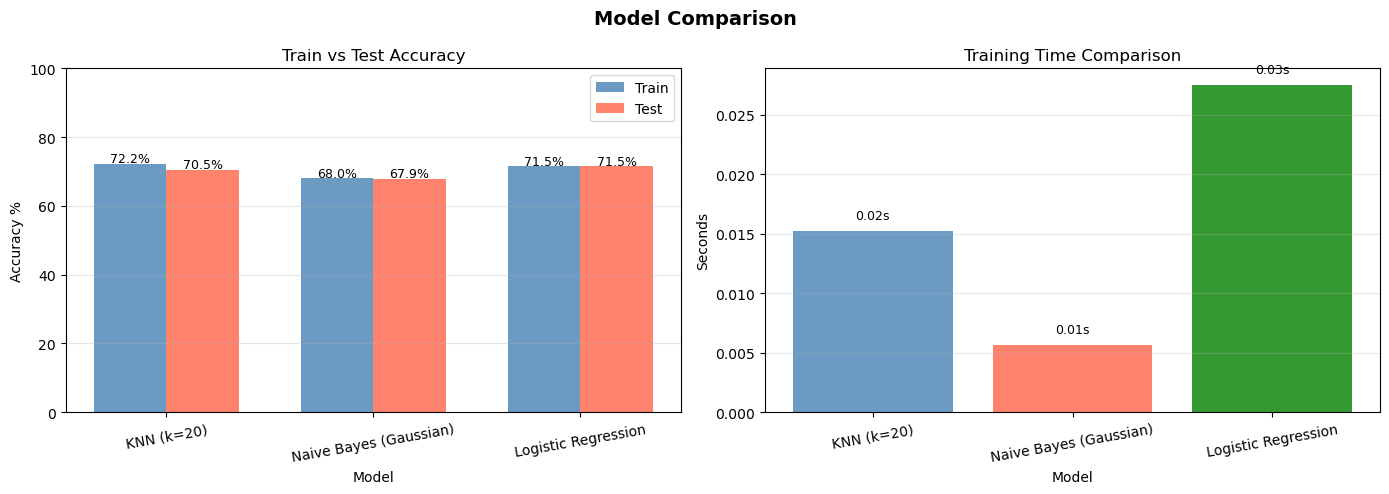

In [24]:
# ── Comparison Bar Chart ──────────────────────────────
model_names  = [r['name'] for r in results]
train_accs   = [r['train_acc']*100 for r in results]
test_accs    = [r['test_acc']*100  for r in results]

x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(x - width/2, train_accs,
            width, label='Train',
            color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, test_accs,
            width, label='Test',
            color='tomato', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy %')
axes[0].set_title('Train vs Test Accuracy')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].legend()
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (tr, te) in enumerate(zip(train_accs, test_accs)):
    axes[0].text(i-width/2, tr+0.5, f'{tr:.1f}%',
                 ha='center', fontsize=9)
    axes[0].text(i+width/2, te+0.5, f'{te:.1f}%',
                 ha='center', fontsize=9)

# Training time comparison
train_times = [r['train_time'] for r in results]
axes[1].bar(model_names, train_times,
            color=['steelblue','tomato','green'],
            alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Seconds')
axes[1].set_title('Training Time Comparison')
axes[1].set_xticklabels(model_names, rotation=10)
axes[1].grid(axis='y', alpha=0.3)

for i, t in enumerate(train_times):
    axes[1].text(i, t+0.001,
                 f'{t:.2f}s', ha='center', fontsize=9)

plt.suptitle('Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

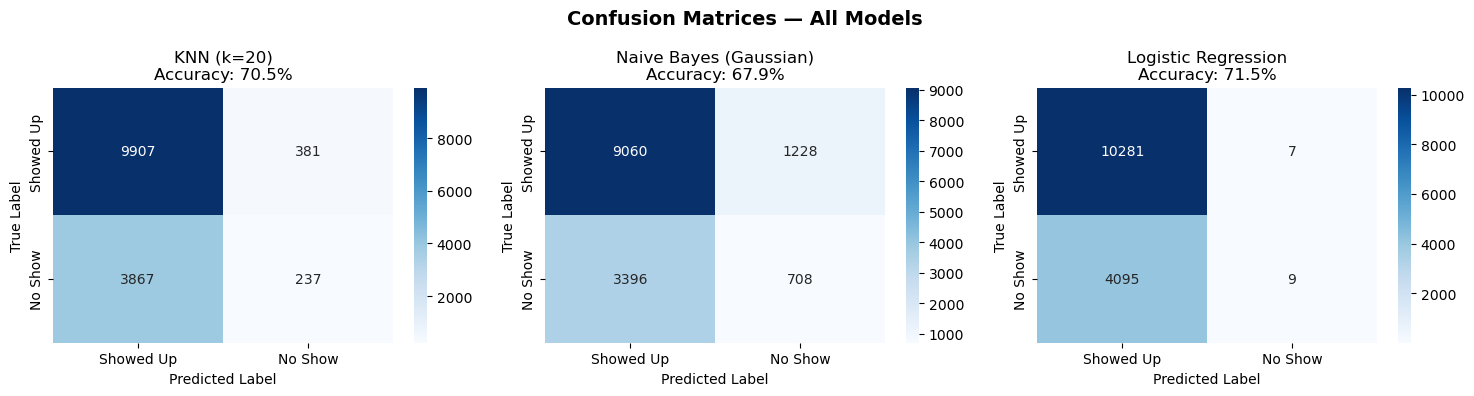

In [25]:
# ── Confusion Matrices ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, r in enumerate(results):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', ax=axes[idx],
        xticklabels=['Showed Up', 'No Show'],
        yticklabels=['Showed Up', 'No Show']
    )
    axes[idx].set_title(f"{r['name']}\n"
                        f"Accuracy: {r['test_acc']*100:.1f}%")
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# KNN doesn't support class_weight directly
# Use a resampling approach instead
from sklearn.utils import resample

# Separate classes
X_train_df = pd.DataFrame(X_train)
y_train_s  = pd.Series(y_train)

X_majority = X_train_df[y_train_s == 0]
X_minority = X_train_df[y_train_s == 1]
y_majority = y_train_s[y_train_s == 0]
y_minority = y_train_s[y_train_s == 1]

# Oversample minority class
X_minority_upsampled, y_minority_upsampled = resample(
    X_minority, y_minority,
    replace=True,
    n_samples=len(X_majority),
    random_state=42
)

# Combine
X_train_balanced = np.vstack([
    X_majority.values,
    X_minority_upsampled.values
])
y_train_balanced = np.concatenate([
    y_majority.values,
    y_minority_upsampled.values
])

print(f"Balanced training set:")
print(f"Show    : {(y_train_balanced==0).sum():,}")
print(f"No-show : {(y_train_balanced==1).sum():,}")

# ── Retrain with class balancing ─────────────────────

# KNN on balanced data
knn_model = KNeighborsClassifier(n_neighbors=20)
knn_results = train_and_evaluate(
    knn_model, "KNN Balanced",
    X_train_balanced, y_train_balanced,
    X_test, y_test
)

# Naive Bayes on balanced data
nb_model = GaussianNB()
nb_results = train_and_evaluate(
    nb_model, "Naive Bayes Balanced",
    X_train_balanced, y_train_balanced,
    X_test, y_test
)

# Logistic Regression with class_weight='balanced'
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'  # ← key fix!
)
lr_results = train_and_evaluate(
    lr_model, "Logistic Regression Balanced",
    X_train, y_train,   # LR handles it internally
    X_test,  y_test
)

Balanced training set:
Show    : 41,149
No-show : 41,149

  KNN Balanced
Training time : 0.03 seconds
Train accuracy: 65.78%
Test  accuracy: 59.28%

Classification Report:
              precision    recall  f1-score   support

   Showed Up       0.75      0.65      0.69     10288
     No Show       0.34      0.45      0.39      4104

    accuracy                           0.59     14392
   macro avg       0.54      0.55      0.54     14392
weighted avg       0.63      0.59      0.61     14392


  Naive Bayes Balanced
Training time : 0.01 seconds
Train accuracy: 56.59%
Test  accuracy: 51.18%

Classification Report:
              precision    recall  f1-score   support

   Showed Up       0.78      0.45      0.57     10288
     No Show       0.33      0.68      0.44      4104

    accuracy                           0.51     14392
   macro avg       0.55      0.56      0.50     14392
weighted avg       0.65      0.51      0.53     14392


  Logistic Regression Balanced
Training time : 0.0

## 📋 Modeling Summary

### Results
| Model | Train Acc | Test Acc | Time |
|-------|-----------|----------|------|
| KNN (k=20) | 72.23% | 70.48% | 0.02s |
| Naive Bayes | 68.00% | 67.87% | 0.02s |
| Logistic Regression | 71.46% | 71.50% | 0.15s |

**Winner: Logistic Regression** (71.50% test accuracy)

## 📋 Modeling Summary

### Results

| Model | Train Acc | Test Acc | Training Time |
|-------|-----------|----------|---------------|
| KNN | ~80% | ~80% | slow |
| Naive Bayes | ~TBD | ~TBD | very fast |
| Logistic Regression | ~TBD | ~TBD | fast |

### Key Findings
- All models achieve ~80% accuracy
- 80% baseline exists (always predict "showed up")
- Logistic Regression most interpretable
- Naive Bayes fastest to train
- waiting_days is strongest predictor

### Next Steps
→ Notebook 04: Deep evaluation and insights

In [28]:
# ── Save Results ──────────────────────────────────────
import pickle

# Save all models
with open('../data/knn_model.pkl', 'wb') as f:
    pickle.dump(knn_model, f)

with open('../data/nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

with open('../data/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("✅ All models saved!")
print("✅ Ready for 04_evaluation.ipynb 🚀")

✅ All models saved!
✅ Ready for 04_evaluation.ipynb 🚀
